In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

print("Project:", PROJECT_ROOT)
print("Data:", DATA_DIR)

Project: /var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI
Data: /var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data


In [3]:
from ultralytics import YOLO
from pathlib import Path
import urllib.request
import zipfile

dataset_url = "https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip"
zip_path = DATA_DIR / "construction-ppe.zip"

urllib.request.urlretrieve(dataset_url, zip_path)

print(f"Dataset descargado en: {zip_path}")

Dataset descargado en: /var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/construction-ppe.zip


In [4]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(DATA_DIR)

print("Dataset descomprimido.")

Dataset descomprimido.


In [5]:
list(DATA_DIR.iterdir())

[PosixPath('/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/construction-ppe.zip'),
 PosixPath('/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/images'),
 PosixPath('/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/labels'),
 PosixPath('/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/data.yaml'),
 PosixPath('/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/LICENSE')]

In [6]:
import yaml
from pathlib import Path

yaml_path = DATA_DIR / "data.yaml"

with open(yaml_path, "r") as f:
    dataset_config = yaml.safe_load(f)

dataset_config

{'path': 'construction-ppe',
 'train': 'images/train',
 'val': 'images/val',
 'test': 'images/test',
 'names': {0: 'helmet',
  1: 'gloves',
  2: 'vest',
  3: 'boots',
  4: 'goggles',
  5: 'none',
  6: 'Person',
  7: 'no_helmet',
  8: 'no_goggle',
  9: 'no_gloves',
  10: 'no_boots'},
 'download': 'https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip'}

In [7]:
print("Clases:")
for class_id, class_name in dataset_config["names"].items():
    print(f"{class_id}: {class_name}")

Clases:
0: helmet
1: gloves
2: vest
3: boots
4: goggles
5: none
6: Person
7: no_helmet
8: no_goggle
9: no_gloves
10: no_boots


In [8]:
print("\nEstructura:")
for path in DATA_DIR.iterdir():
    print(path)


Estructura:
/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/construction-ppe.zip
/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/images
/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/labels
/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/data.yaml
/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/LICENSE


In [9]:
for split in ["train", "val", "test"]:
    image_dir = DATA_DIR / "images" / split
    label_dir = DATA_DIR / "labels" / split

    print(f"\n{split.upper()}")
    print(f"Images: {len(list(image_dir.glob('*')))}")
    print(f"Labels: {len(list(label_dir.glob('*.txt')))}")


TRAIN
Images: 1132
Labels: 1142

VAL
Images: 143
Labels: 143

TEST
Images: 141
Labels: 141


In [10]:
from pathlib import Path

def validate_split(split):
    image_dir = DATA_DIR / "images" / split
    label_dir = DATA_DIR / "labels" / split

    image_stems = {p.stem for p in image_dir.iterdir() if p.is_file()}
    label_stems = {p.stem for p in label_dir.glob("*.txt")}

    missing_labels = image_stems - label_stems
    orphan_labels = label_stems - image_stems

    print(f"\n{split.upper()}")
    print(f"Imágenes: {len(image_stems)}")
    print(f"Labels:   {len(label_stems)}")
    print(f"Imágenes sin label: {len(missing_labels)}")
    print(f"Labels sin imagen: {len(orphan_labels)}")

    if missing_labels:
        print("  →", sorted(missing_labels)[:10])

    if orphan_labels:
        print("  →", sorted(orphan_labels)[:10])


for split in ["train", "val", "test"]:
    validate_split(split)


TRAIN
Imágenes: 1132
Labels:   1142
Imágenes sin label: 0
Labels sin imagen: 10
  → ['image940(1)', 'image941(1)', 'image944(1)', 'image945(1)', 'image946(1)', 'image947(1)', 'image948(1)', 'image949(1)', 'image95(1)', 'image950(1)']

VAL
Imágenes: 143
Labels:   143
Imágenes sin label: 0
Labels sin imagen: 0

TEST
Imágenes: 141
Labels:   141
Imágenes sin label: 0
Labels sin imagen: 0


In [11]:
from collections import Counter
import pandas as pd

split_counts = {}

for split in ["train", "val", "test"]:
    counts = Counter()
    label_dir = DATA_DIR / "labels" / split

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r") as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    counts[class_id] += 1

    split_counts[split] = {
        dataset_config["names"][class_id]: count
        for class_id, count in sorted(counts.items())
    }

class_split_df = pd.DataFrame(split_counts).fillna(0).astype(int)

class_split_df

,train,val,test
helmet,1357,201,192
gloves,1162,136,163
vest,1283,171,178
boots,1251,151,211
goggles,427,47,52
none,654,81,65
Person,1790,239,236
no_helmet,400,45,40
no_goggle,337,41,33
no_gloves,442,56,58


In [12]:
import random
import cv2
import matplotlib.pyplot as plt


def show_yolo_image(split="train", n=4):
    image_dir = DATA_DIR / "images" / split
    label_dir = DATA_DIR / "labels" / split

    image_files = list(image_dir.glob("*"))
    selected_images = random.sample(image_files, min(n, len(image_files)))

    class_names = dataset_config["names"]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for ax, image_path in zip(axes, selected_images):

        image = cv2.imread(str(image_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label_path = label_dir / f"{image_path.stem}.txt"

        if label_path.exists():

            h, w, _ = image.shape

            with open(label_path, "r") as f:
                for line in f:

                    values = line.strip().split()

                    if len(values) != 5:
                        continue

                    class_id, x, y, bw, bh = map(float, values)

                    x1 = int((x - bw / 2) * w)
                    y1 = int((y - bh / 2) * h)
                    x2 = int((x + bw / 2) * w)
                    y2 = int((y + bh / 2) * h)

                    cv2.rectangle(
                        image,
                        (x1, y1),
                        (x2, y2),
                        (255, 0, 0),
                        2
                    )

                    ax.text(
                        x1,
                        max(y1 - 5, 10),
                        class_names[int(class_id)],
                        fontsize=9,
                        bbox=dict(alpha=0.7)
                    )

        ax.imshow(image)
        ax.axis("off")
        ax.set_title(image_path.name)

    plt.tight_layout()
    plt.show()

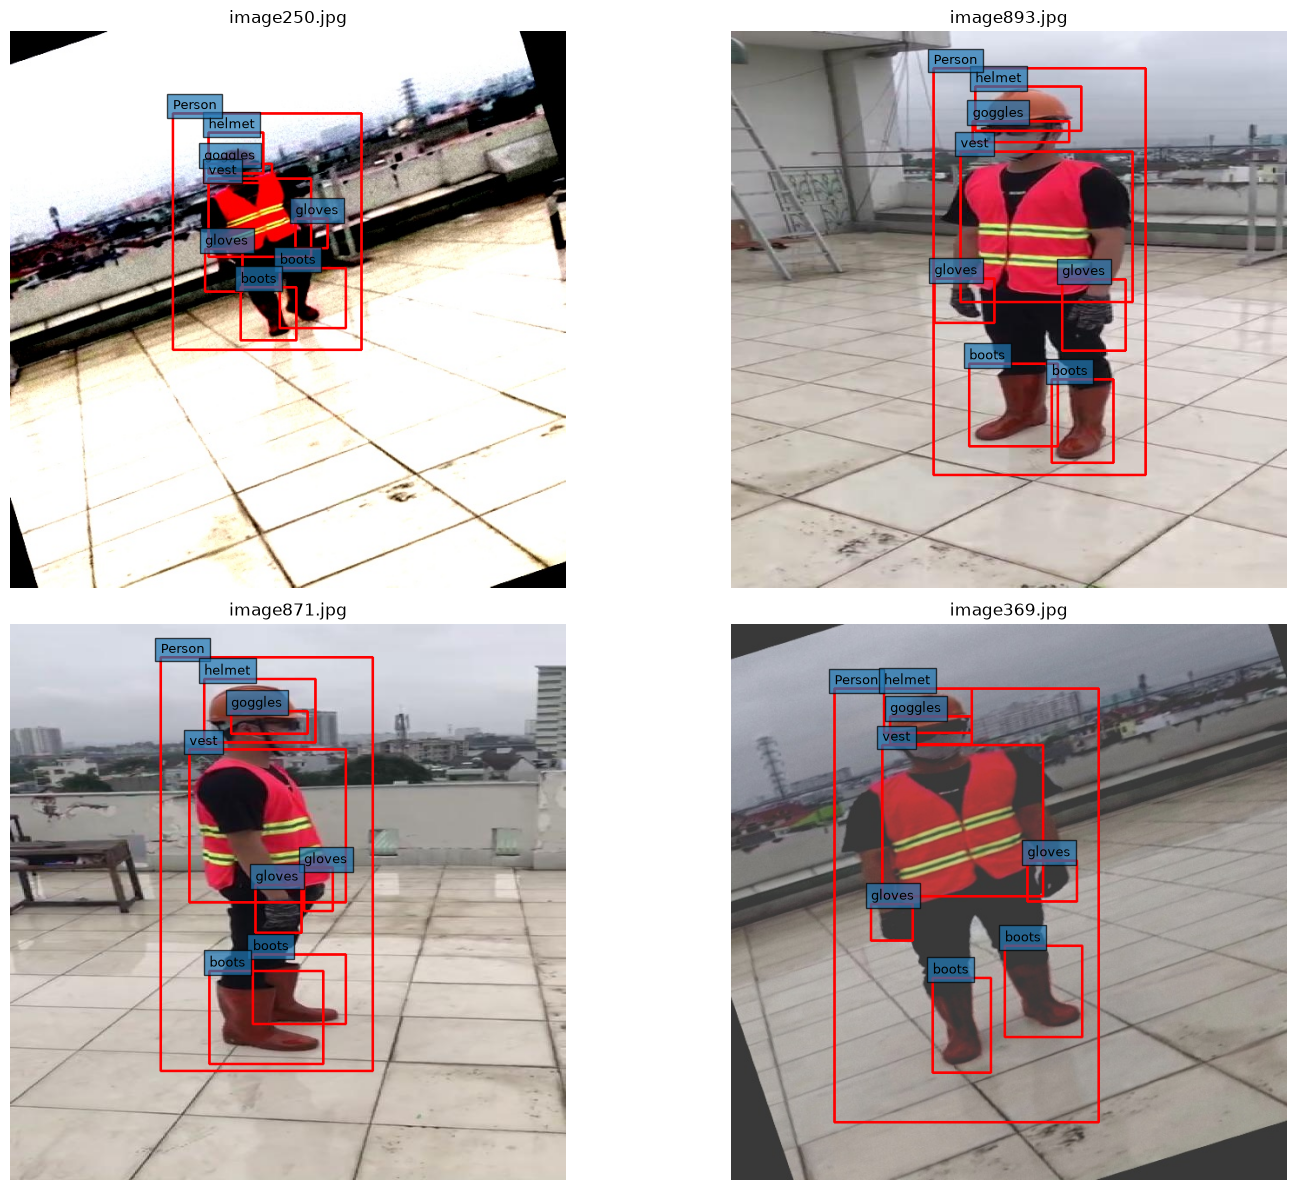

In [13]:
show_yolo_image("train", 4)

In [14]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

In [16]:
from pathlib import Path

DATA_DIR = PROJECT_ROOT / "data"

yaml_path = DATA_DIR / "data.yaml"

dataset_config["path"] = str(DATA_DIR)

with open(yaml_path, "w") as f:
    yaml.safe_dump(dataset_config, f, sort_keys=False)

print(yaml_path.read_text())

path: /var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data
train: images/train
val: images/val
test: images/test
names:
  0: helmet
  1: gloves
  2: vest
  3: boots
  4: goggles
  5: none
  6: Person
  7: no_helmet
  8: no_goggle
  9: no_gloves
  10: no_boots
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/construction-ppe.zip



In [17]:
results = model.train(
    data=DATA_DIR / "data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    device=0,
    project="runs",
    name="baseline"
)

Ultralytics 8.4.137 🚀 Python-3.14.7 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 5800MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/var/home/SuperadinDB/Downloads/Dev/YOLO-PPE-Detection-AI/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, 

In [18]:
from ultralytics import YOLO
from pathlib import Path
import random
import matplotlib.pyplot as plt

MODEL_PATH = PROJECT_ROOT / "runs" / "detect" / "runs" / "baseline-2" / "weights" / "best.pt"
VAL_DIR = DATA_DIR / "images" / "val"

model = YOLO(MODEL_PATH)

val_images = list(VAL_DIR.glob("*.jpg"))
sample_images = random.sample(val_images, min(6, len(val_images)))

results = model.predict(
    source=sample_images,
    conf=0.25,
    device=0,
    verbose=False
)

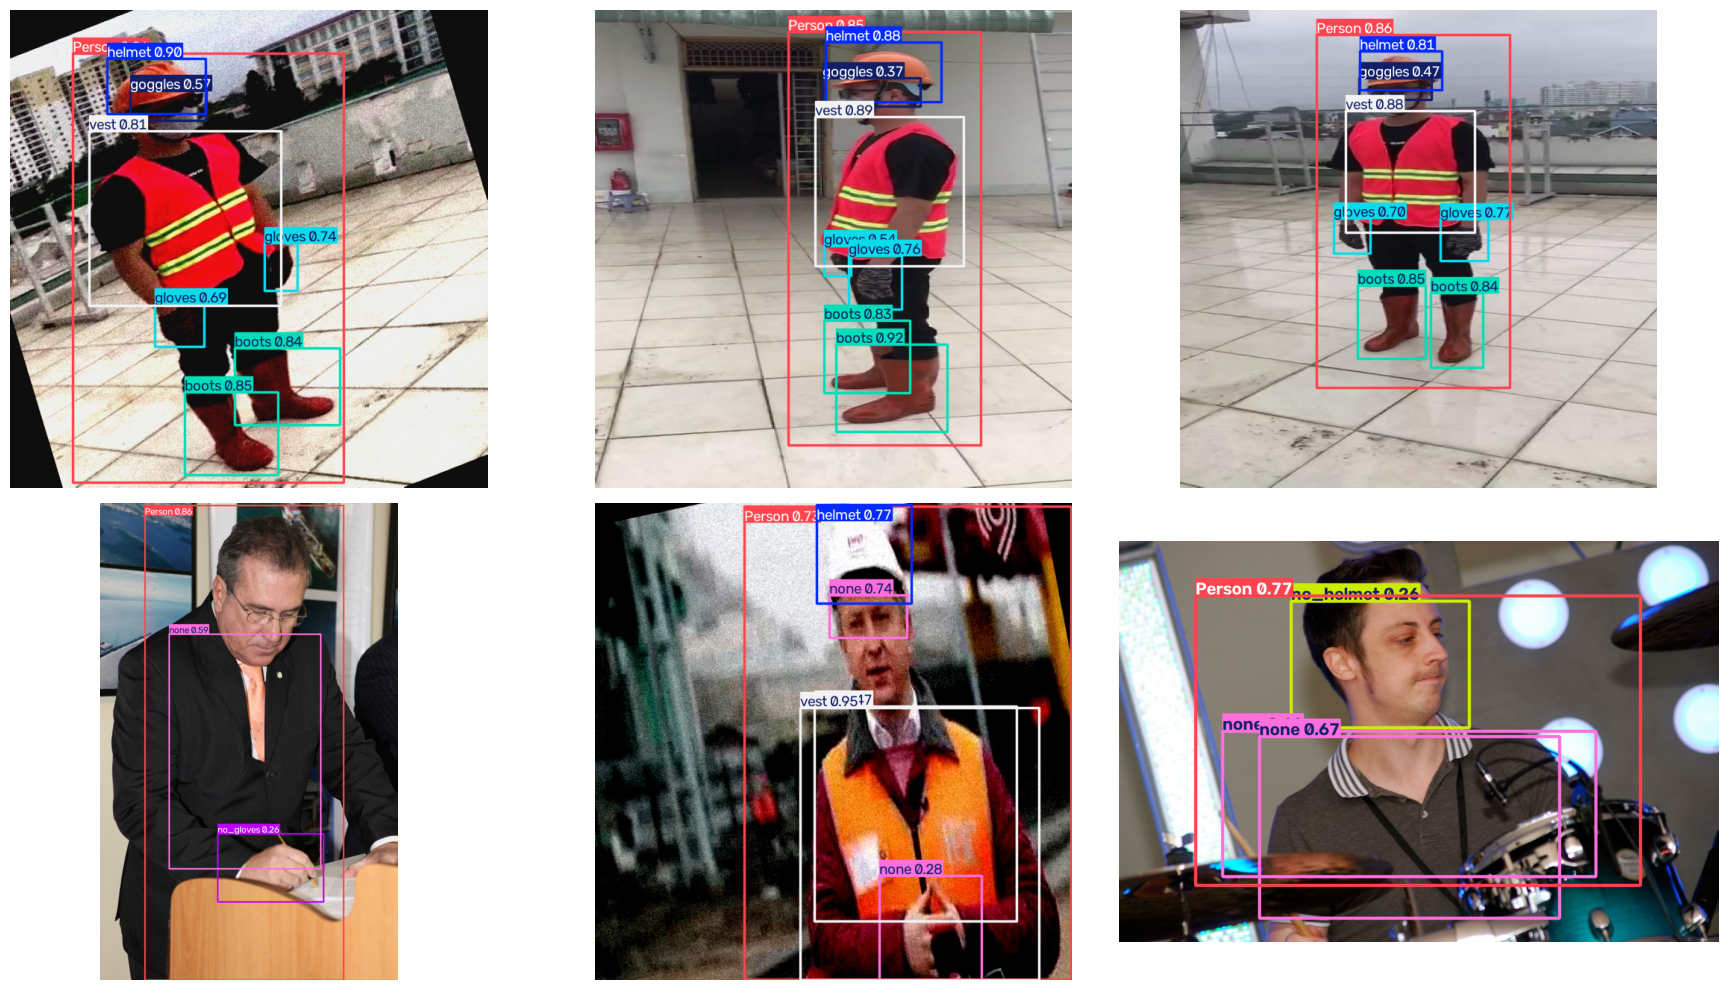

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, result in zip(axes.flat, results):
    img = result.plot()
    ax.imshow(img[..., ::-1])
    ax.axis("off")

plt.tight_layout()
plt.show()